# Cell 1 — Install Dependencies

In [1]:
!pip -q install torch torchvision transformers clip-anytorch scikit-learn nltk pycocoevalcap seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


# Cell 2 — Imports

In [2]:
# We import all required libraries used throughout the research pipeline.

import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import clip
from transformers import GPT2Tokenizer, GPT2LMHeadModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import nltk
nltk.download('punkt')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Cell 3 — Create Project Structure

In [3]:
# We organize all experiment artifacts into structured directories to ensure
# reproducibility and consistent checkpointing.

BASE_DIR = "/kaggle/working/project"

dirs = [
    "processed_data",
    "models",
    "plots",
    "predictions",
    "checkpoints"
]

for d in dirs:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

print("Project directories created.")

Project directories created.


# Cell 4 — Dataset Paths

In [6]:
# We define dataset locations based on Kaggle input paths.

multimodal_base = "/kaggle/input/datasets/ziya07/multimodal-artistic-style-conversion-dataset"
multimodal_images = os.path.join(multimodal_base, "images/images")
multimodal_caption_file = os.path.join(multimodal_base, "ArtCap.json")

artemis_base = "/kaggle/input/datasets/rollas/artemis-dataset-including-10k-images"
artemis_images = os.path.join(artemis_base, "images")
artemis_csv = os.path.join(artemis_base, "dataset_final.csv")

# Cell 5 — Load Multimodal Caption Dataset

In [7]:
# We load the multimodal caption dataset where each image contains five captions.

with open(multimodal_caption_file, "r") as f:
    multimodal_data = json.load(f)

rows = []

for img_name, captions in multimodal_data.items():
    img_path = os.path.join(multimodal_images, img_name)
    
    for c in captions:
        rows.append({
            "image_path": img_path,
            "caption": c,
            "emotion": "unknown",
            "source": "multimodal"
        })

multimodal_df = pd.DataFrame(rows)
print("Multimodal samples:", len(multimodal_df))
multimodal_df.head()

Multimodal samples: 18030


,image_path,caption,emotion,source
0,/kaggle/input/datasets/ziya07/multimodal-artis...,cow with female farmer out in the field,unknown,multimodal
1,/kaggle/input/datasets/ziya07/multimodal-artis...,the image summarize cow eating,unknown,multimodal
2,/kaggle/input/datasets/ziya07/multimodal-artis...,this painting shows cows in pasture,unknown,multimodal
3,/kaggle/input/datasets/ziya07/multimodal-artis...,cow has some legs milk has vitamine c,unknown,multimodal
4,/kaggle/input/datasets/ziya07/multimodal-artis...,a cow with a lady poping her head up from the ...,unknown,multimodal


# Cell 6 — Load ArtEmis Dataset

In [8]:
# We load the ArtEmis dataset containing emotional descriptions of paintings.

artemis_df = pd.read_csv(artemis_csv)

artemis_df = artemis_df[["painting", "utterance", "emotion"]]

artemis_df["image_path"] = artemis_df["painting"].apply(
    lambda x: os.path.join(artemis_images, f"{x}.jpg")
)

artemis_df.rename(columns={"utterance":"caption"}, inplace=True)
artemis_df["source"] = "artemis"

artemis_df = artemis_df[["image_path","caption","emotion","source"]]

print("Artemis samples:", len(artemis_df))
artemis_df.head()

Artemis samples: 49056


,image_path,caption,emotion,source
0,/kaggle/input/datasets/rollas/artemis-dataset-...,This painting shows a gloomy day. The darkness...,sadness,artemis
1,/kaggle/input/datasets/rollas/artemis-dataset-...,the weather and atmosphere makes me feel sad,sadness,artemis
2,/kaggle/input/datasets/rollas/artemis-dataset-...,"Dark and moody, cloudy sky that is depressing",sadness,artemis
3,/kaggle/input/datasets/rollas/artemis-dataset-...,the picture is dark with a somber tone,sadness,artemis
4,/kaggle/input/datasets/rollas/artemis-dataset-...,the dark colors make the painting look gloomy,sadness,artemis


# Cell 7 — Combine Datasets

In [9]:
# We merge the two datasets and remove rows where images are missing.

data = pd.concat([multimodal_df, artemis_df], ignore_index=True)

data = data[data.image_path.apply(os.path.exists)]

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total dataset size:", len(data))
data.head()

Total dataset size: 67086


,image_path,caption,emotion,source
0,/kaggle/input/datasets/rollas/artemis-dataset-...,The man does not look very friendly based off ...,disgust,artemis
1,/kaggle/input/datasets/ziya07/multimodal-artis...,"a child is walking on a path , and a woman l...",unknown,multimodal
2,/kaggle/input/datasets/ziya07/multimodal-artis...,a mob of people is standing in a huddle with a...,unknown,multimodal
3,/kaggle/input/datasets/rollas/artemis-dataset-...,You got to give it up for any chubby women in ...,awe,artemis
4,/kaggle/input/datasets/ziya07/multimodal-artis...,two children gather flowers from low-hanging b...,unknown,multimodal


# Cell 8 — Train / Validation / Test Split

In [10]:
# We perform a strict split to prevent data leakage.

train_df, temp_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

train_df.to_csv(f"{BASE_DIR}/processed_data/train.csv", index=False)
val_df.to_csv(f"{BASE_DIR}/processed_data/val.csv", index=False)
test_df.to_csv(f"{BASE_DIR}/processed_data/test.csv", index=False)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 53668
Validation: 6709
Test: 6709


# Cell 9 — Load CLIP Model

In [11]:
# We load the CLIP vision encoder which provides a strong representation
# of the visual content.

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

100%|███████████████████████████████████████| 354M/354M [00:05<00:00, 61.6MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

# Cell 10 — Extract CLIP Features

In [13]:
# We compute image embeddings using CLIP while handling truncated or corrupted images
# that occasionally appear in large art datasets.

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def extract_features(df):

    features = []
    valid_indices = []

    for idx, img_path in enumerate(tqdm(df.image_path)):

        try:
            image = Image.open(img_path).convert("RGB")
            image = clip_preprocess(image).unsqueeze(0).to(device)

            with torch.no_grad():
                emb = clip_model.encode_image(image)

            features.append(emb.cpu().numpy()[0])
            valid_indices.append(idx)

        except Exception as e:
            continue

    features = np.array(features)
    df = df.iloc[valid_indices].reset_index(drop=True)

    return features, df


train_features, train_df = extract_features(train_df)
val_features, val_df = extract_features(val_df)
test_features, test_df = extract_features(test_df)


np.save(f"{BASE_DIR}/processed_data/train_features.npy", train_features)
np.save(f"{BASE_DIR}/processed_data/val_features.npy", val_features)
np.save(f"{BASE_DIR}/processed_data/test_features.npy", test_features)

print("Feature extraction completed.")

 16%|█▋        | 8748/53668 [04:47<18:35, 40.27it/s]  /usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (99962094 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 6709/6709 [03:44<00:00, 29.94it/s]


Feature extraction completed.


# Cell 11 — Emotion Label Encoding

In [14]:
# We convert emotion labels into numeric classes for classification.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_emotions = le.fit_transform(train_df.emotion)
val_emotions = le.transform(val_df.emotion)
test_emotions = le.transform(test_df.emotion)

num_classes = len(le.classes_)

print("Emotion classes:", num_classes)

Emotion classes: 9


# Cell 12 — Concept Predictor Model

In [15]:
# We implement a lightweight classifier that predicts semantic concepts
# based on CLIP visual features.

class ConceptPredictor(nn.Module):
    
    def __init__(self, input_dim=512, hidden=256, num_classes=10):
        
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

model = ConceptPredictor(512,256,num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Cell 13 — Resume Checkpoint

In [16]:
checkpoint_path = f"{BASE_DIR}/checkpoints/concept_model.pt"

start_epoch = 0

if os.path.exists(checkpoint_path):
    
    checkpoint = torch.load(checkpoint_path)
    
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"]
    
    print("Checkpoint loaded")

# Cell 14 — Training Loop

In [17]:
EPOCHS = 5

train_features_t = torch.tensor(train_features).float().to(device)
train_labels_t = torch.tensor(train_emotions).long().to(device)

val_features_t = torch.tensor(val_features).float().to(device)
val_labels_t = torch.tensor(val_emotions).long().to(device)

train_losses = []
val_losses = []

for epoch in range(start_epoch, EPOCHS):
    
    model.train()
    
    optimizer.zero_grad()
    
    outputs = model(train_features_t)
    
    loss = criterion(outputs, train_labels_t)
    
    loss.backward()
    
    optimizer.step()
    
    train_losses.append(loss.item())
    
    model.eval()
    
    with torch.no_grad():
        
        val_outputs = model(val_features_t)
        
        val_loss = criterion(val_outputs, val_labels_t)
        
        val_losses.append(val_loss.item())
    
    print(f"Epoch {epoch+1}")
    print("Train Loss:", loss.item())
    print("Val Loss:", val_loss.item())
    
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch+1
    }, checkpoint_path)

Epoch 1
Train Loss: 2.191495418548584
Val Loss: 2.065190076828003
Epoch 2
Train Loss: 2.0667951107025146
Val Loss: 1.9559710025787354
Epoch 3
Train Loss: 1.959660530090332
Val Loss: 1.8615373373031616
Epoch 4
Train Loss: 1.8658332824707031
Val Loss: 1.7855842113494873
Epoch 5
Train Loss: 1.7916673421859741
Val Loss: 1.7325564622879028


# Cell 15 — Training Curve Plot

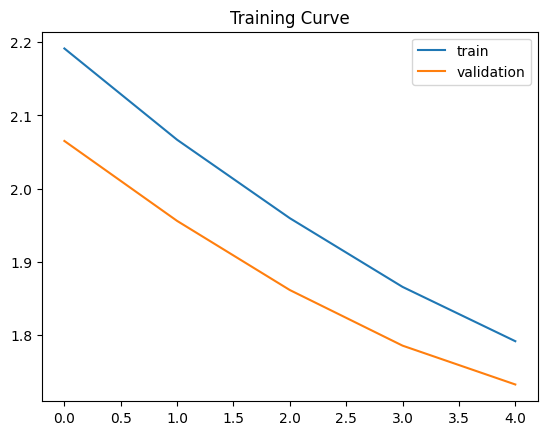

In [18]:
plt.figure()

plt.plot(train_losses,label="train")
plt.plot(val_losses,label="validation")

plt.legend()
plt.title("Training Curve")

plt.savefig(f"{BASE_DIR}/plots/loss_curve.png")

plt.show()

# Cell 16 — Evaluation

In [19]:
model.eval()

test_features_t = torch.tensor(test_features).float().to(device)

with torch.no_grad():
    
    logits = model(test_features_t)
    
preds = logits.argmax(1).cpu().numpy()

print(classification_report(test_emotions,preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        92
           1       0.00      0.00      0.00       341
           2       0.00      0.00      0.00       163
           3       0.00      0.00      0.00       440
           4       0.00      0.00      0.00       745
           5       0.00      0.00      0.00       150
           6       0.30      0.08      0.13      1214
           7       0.35      0.57      0.43      1812
           8       0.48      0.94      0.63      1752

    accuracy                           0.41      6709
   macro avg       0.13      0.18      0.13      6709
weighted avg       0.27      0.41      0.31      6709



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cell 17 — Confusion Matrix

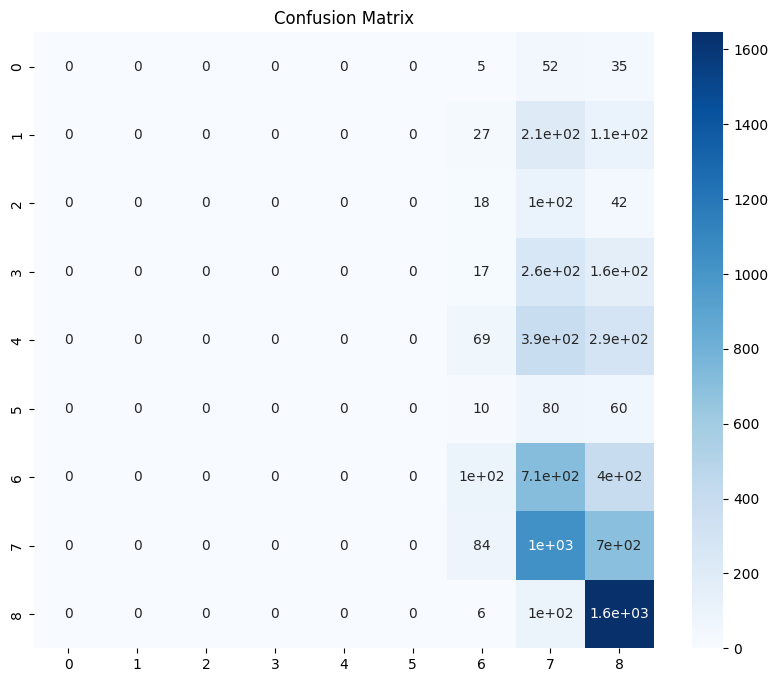

In [20]:
cm = confusion_matrix(test_emotions,preds)

plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(f"{BASE_DIR}/plots/confusion_matrix.png")

plt.show()

# Cell 18 — Metrics

In [21]:
precision = precision_score(test_emotions,preds,average="weighted")
recall = recall_score(test_emotions,preds,average="weighted")
f1 = f1_score(test_emotions,preds,average="weighted")

print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)

Precision: 0.274371936016548
Recall: 0.4139215978536295
F1: 0.3065385861142788


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cell 19 — Caption Generation Model

In [22]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

gpt_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

# Cell 20 — Generate Captions

In [23]:
examples = test_df.sample(10)

results = []

for idx,row in examples.iterrows():
    
    prompt = row.caption[:50]
    
    inputs = tokenizer.encode(prompt,return_tensors="pt").to(device)
    
    outputs = gpt_model.generate(
        inputs,
        max_length=40,
        num_beams=3
    )
    
    caption = tokenizer.decode(outputs[0],skip_special_tokens=True)
    
    results.append({
        "image":row.image_path,
        "generated_caption":caption
    })

results_df = pd.DataFrame(results)

results_df.to_csv(f"{BASE_DIR}/predictions/generated_captions.csv",index=False)

results_df.head()

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask

,image,generated_caption
0,/kaggle/input/datasets/ziya07/multimodal-artis...,the girl with curly hair sat on the ground pla...
1,/kaggle/input/datasets/ziya07/multimodal-artis...,a lady in brown on a bench in the park with he...
2,/kaggle/input/datasets/ziya07/multimodal-artis...,"an audience waits for the show to begin.\n\n""I..."
3,/kaggle/input/datasets/rollas/artemis-dataset-...,The image shows the drudgery of manual labor. ...
4,/kaggle/input/datasets/rollas/artemis-dataset-...,I think what the photo itself represents is ab...


# Cell 21 — Visual Examples

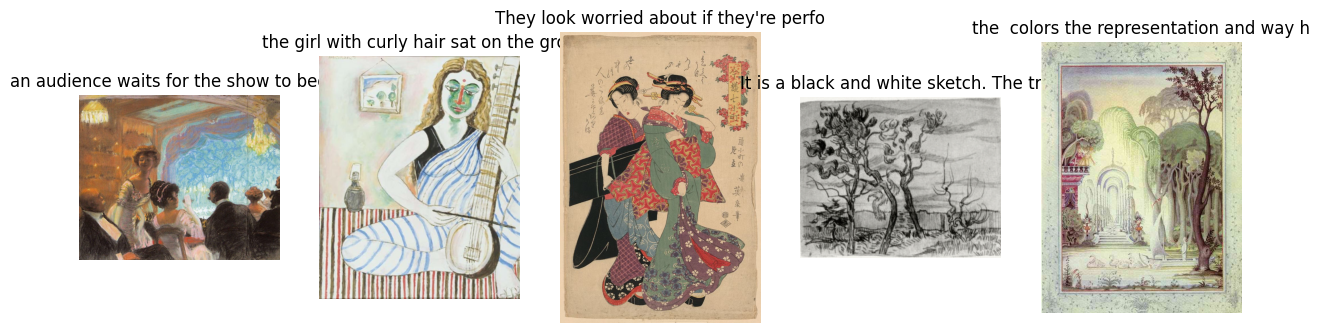

In [24]:
samples = results_df.sample(5)

plt.figure(figsize=(15,8))

for i,(idx,row) in enumerate(samples.iterrows()):
    
    img = Image.open(row.image)
    
    plt.subplot(1,5,i+1)
    
    plt.imshow(img)
    
    plt.title(row.generated_caption[:40])
    
    plt.axis("off")

plt.savefig(f"{BASE_DIR}/plots/sample_predictions.png")

plt.show()

In [ ]:
import os
import shutil

folder_to_zip = '/kaggle/working/project' 
output_filename = 'results'

shutil.make_archive(output_filename, 'zip', folder_to_zip)

'/kaggle/working/results.zip'